# Open Assignment: Machine Learning

**Program: Digital Technology** 

- Semester: I
- Subject: AI-CR-501/DS-CR-503 Machine Learning 
- Level: Masters In Applied Science 

#### Question 1: Linear Regression

**`Provide your own Python implementation of Linear Regression following the mathematical description provided in the class.`**

**`Write a simple data generator to generate data for age vs height showing transition points where the height increases sharply (see lecture slides).`**

**`Include knot points to model transition points into your feature modelling. Train your model in the synthetic data you have generated.`** 

**`Plot loss curves against training epochs. Plot your model prediction against ground truth data.`**

**`Compare your model output against sklearn implementation of linear regression.`**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

# GENERATING AGE AND HEIGHT DATA

import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

ages = np.random.uniform(1, 18, 200)
heights = np.zeros(200)


# Create height data
for i, age in enumerate(ages):

    base_height = 50 + 5 * age

    # Growth changes after age 10
    heihgt_1 = 3 * max(0, age - 10)

    # Growth changes again after age 15
    height_2 = 7 * max(0, age - 15)

    # Add some random noise
    noise = np.random.normal(0, 2.5)

    heights[i] = base_height + heihgt_1 + height_2 + noise

# Knot points
knot1 = 5
knot2 = 12

# Create the feature matrix
X = np.column_stack([
    np.ones(len(ages)),
    ages,
    np.maximum(0, ages - knot1),
    np.maximum(0, ages - knot2)
])

y = heights.reshape(-1, 1)


# LINEAR REGRESSION FROM SCRATCH by GRADIENT DESCENT METHOD
learning_rate = 0.01
epochs = 1000

# Start all weights at 0
weights = np.zeros((X.shape[1], 1))

# Store loss after every epoch
loss_history = []

# Gradient descent
for epoch in range(epochs):

    predictions = X.dot(weights)

    error = predictions - y

    # Calculate loss
    loss = (1 / (2 * len(X))) * np.sum(error ** 2)

    loss_history.append(loss)

    # Calculate gradients
    gradients = (1 / len(X)) * X.T.dot(error)
    
    # Update weights
    weights = weights - learning_rate * gradients


# Print learned weights
print("Weights learned by our model:")
print(weights.flatten())


Weights learned by our model:
[22.05733761 11.79613351 -7.67246365  7.5697959 ]


Weights learned by sklearn:
[52.23097191  4.37079432  1.10015932  5.58569662]


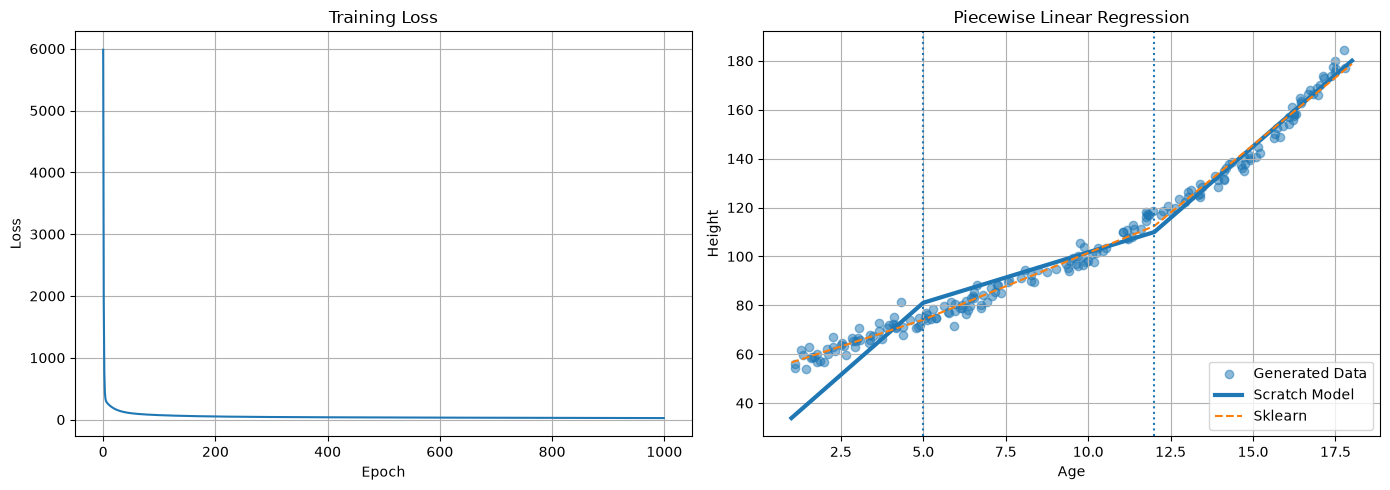

In [5]:
# Compare with sklearn

from sklearn.linear_model import LinearRegression

# We already have a column of 1s in X,
# so we don't need another intercept.
sklearn_model = LinearRegression(fit_intercept=False)

sklearn_model.fit(X, y)

print("Weights learned by sklearn:")
print(sklearn_model.coef_.flatten())


# Create smooth age values for plotting
smooth_ages = np.linspace(1, 18, 500)

# Create the same knot features for smooth_ages
X_smooth = np.column_stack([
    np.ones(len(smooth_ages)),
    smooth_ages,
    np.maximum(0, smooth_ages - knot1),
    np.maximum(0, smooth_ages - knot2)
])

# Predictions from our model
scratch_predictions = X_smooth.dot(weights)

# Predictions from sklearn
sklearn_predictions = sklearn_model.predict(X_smooth)

# PLOTS

plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)


# Data and predictions
plt.subplot(1, 2, 2)

# Original generated data
plt.scatter(
    ages,
    heights,
    alpha=0.5,
    label="Generated Data"
)


# Our model prediction
plt.plot(
    smooth_ages,
    scratch_predictions,
    linewidth=3,
    label="Scratch Model"
)

# Sklearn prediction
plt.plot(
    smooth_ages,
    sklearn_predictions,
    linestyle="--",
    label="Sklearn"
)

# Show the knot points
plt.axvline(
    knot1,
    linestyle=":"
)

plt.axvline(
    knot2,
    linestyle=":"
)


plt.title("Piecewise Linear Regression")
plt.xlabel("Age")
plt.ylabel("Height")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Question 2: Regularization

**Provide your own Python implementation of Ridge Regression and Lasso 
Regression following the mathematical description provided in the class.**

**For the `a. age` vs `height` data and from Q1 and 	`b. cancer dataset` from HTF (Elements of Statistical Learning) book. Apply your Ridge regression and Lasso regression to automatically eliminate features that are not highly relevant. Try this for different values of lambda.

**Compare your model output against sklearn implementation of Ridge and Lasso linear 
regression. Please note that sklearn implementation of both are a bit different from the one described in class. Understand these differences.**

In particular, in our class, we used the following loss function for Ridge regression:
′

whereas, in sklearn, the following loss function is employed:

Change your loss function to the above used within sklearn and re-run your code. 

#### Ridge Regression Implementation

In [11]:
import numpy as np

class RidgeRegression:
    def __init__(self, learning_rate=0.01, lambda_value=0.5, n_iterations=1000):
        self.lr = learning_rate
        self.lam = lambda_value 
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.n_iterations):
          
            # Calculate predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Compute gradients for the base loss (MSE)
            dw_mse = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            db_mse = (2 / n_samples) * np.sum(y_predicted - y)

            # Apply the lambda weighting and regularization penalty
            # dw = lambda * dw_mse + (1 - lambda) * 2w
            dw = self.lam * dw_mse + (1 - self.lam) * 2 * self.weights
            
            # db = lambda * db_mse (Bias is not regularized)
            db = self.lam * db_mse

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# --- Example Usage ---
if __name__ == "__main__":
    # Dummy data
    X_train = np.array([[1, 2], [2, 3], [4, 5], [3, 6]])
    y_train = np.array([3, 5, 7, 8])

    # Initialize and train model
    model = RidgeRegression(learning_rate=0.01, lambda_value=0.8, n_iterations=1000)
    model.fit(X_train, y_train)

    print("Learned Weights:", model.weights)
    print("Learned Bias:", model.bias)

Learned Weights: [0.35648755 0.92058412]
Learned Bias: 1.1605705791310563


#### Lasso Regression Implementation

In [ ]:
class LassoRegression:
    def __init__(self, learning_rate=0.01, lambda_value=0.5, n_iterations=1000):
        self.lr = learning_rate
        self.lam = lambda_value
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent loop
        for _ in range(self.n_iterations):
            # Calculate predictions (y_hat)
            y_predicted = np.dot(X, self.weights) + self.bias

            # 1. Compute gradients for the base loss (MSE scaling used for stability)
            # Factoring the negative sign into (y_predicted - y)
            dw_base = (2 / n_samples) * np.dot(X.T, (y_predicted - y))
            db_base = (2 / n_samples) * np.sum(y_predicted - y)

            # 2. Apply the lambda weighting and the L1 subgradient penalty
            # np.sign() returns -1 if x < 0, 0 if x==0, 1 if x > 0
            dw = self.lam * dw_base + (1 - self.lam) * np.sign(self.weights)
            
            # db = lambda * db_base (Bias is not regularized)
            db = self.lam * db_base

            # 3. Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# --- Example Usage ---
if __name__ == "__main__":
    # Dummy data
    X_train = np.array([[1, 2], [2, 3], [4, 5], [3, 6]])
    y_train = np.array([3, 5, 7, 8])

    # Initialize and train model
    model = CustomLassoRegression(learning_rate=0.01, lambda_param=0.8, n_iterations=1000)
    model.fit(X_train, y_train)

    print("Learned Weights:", model.weights)
    print("Learned Bias:", model.bias)